# MLP (Multi-Layer-Perceptron) with Categorical Embeddings
## ----- NFL TV Ratings (Neural Network)

## About This Notebook

This notebook assumes familiarity with the MLP
fundamentals (ReLU, weight initialization, forward/backprop, Adam) found in `MLP_tv_ratings.ipynb`.
It is recommended to read that notebook first. 

The three shared modules are:

- `MLP_core.py`: MLP primitives (forward/backprop, Adam optimizer, activation functions)
- `tv_ratings_preprocessing.py`: data preparation (helper functions and feature engineering)
- `MLP_analysis.py`: post-training analysis (run_permutation_importance, plot_actual_vs_predicted)

What is new here: Machine-learned entity embeddings, bilinear team×market interaction matrix,
per-entity embedding dropout, and embedding space analysis (PCA, cosine similarity,
bilinear W heatmap).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score

# custom module imports
from tv_ratings_preprocessing import isdivision, encode_categorical, build_concurrent_features, build_normalized_market_draw
from MLP_core import (relu, deriv_relu, mse_loss, init_params, init_adam_state,
                      update_params_adam, forward_prop, back_prop)
from MLP_analysis import run_permutation_importance, plot_actual_vs_predicted, plot_subset_r2

## 1. Data Loading

In [2]:
# The table located at data_path is the final result of our SQL project which can also be found in the repo
data_path = r'C:/Users/ASR10/PyPr/nfl_python_local/111B/nfl_python/nfl_data_pipeline/NFLTV_ML_11_rebuilt.csv'
df = pd.read_csv(data_path)
df = df[df['Day'] == 'Sun'].copy()                  # removes any prime time games that snuck into the dataset.
df = df[df['timeofday'] != 'morning'].copy()        # rule out international games (a subset of prime-time games, they take place primarily on sunday morning)
df = df.sort_values('Date').reset_index(drop=True)


predictors_numerical = ['prev_market_at_year_avg',
'prev_market_ht_year_avg',
'prev_year_at_market_trend_todate',
'prev_year_ht_market_trend_todate',
'prev_year_at_market_trend_4',
'prev_year_ht_market_trend_4',
'prev_year_market_tod_avg',
'prev_market_tod_trend_todate',
'prev_market_tod_trend_4',
'ht_market_todate_prediction',
'ht_market_4_prediction',
'at_market_todate_prediction',
'at_market_4_prediction',
'market_tod_todate_prediction',
'market_tod_4_prediction',
'ht_expected_wins',
'at_expected_wins',
'sum_expected_wins',
'sumwins_m_difwins',
'sumwins_m_difwins_d_week',
'ht_playoff_make_prob',
'ht_playoff_miss_prob',
'at_playoff_make_prob',
'at_playoff_miss_prob',
'ht_division_prob',
'at_division_prob',
'ht_conference_prob',
'at_conference_prob',
'ht_superbowl_prob',
'at_superbowl_prob',
'diff_playoff_make_prob',
'diff_playoff_miss_prob',
'diff_wins',
'sumwins2_diffwins2',
'diff_division_prob',
'diff_conference_prob',
'diff_superbowl_prob',
'normalized_ht_market_draw',
'normalized_at_market_draw',
'week']

predictors_bool = ['playoff_rematch', 'brady', 'rodgers', 'mahomes']  # boolean features, passthrough, already one-hot-encoded

predictors_nominal = [  # Categorical, need to be one-hot-encoded
'timeofday',
'Affiliation'
]

predictors_embed = [  # features to be embedded
    'at_code',           # configured below
    'ht_code',           # configured_below
    'window_code',       # configured_below
    'div_matchup_code'   # configured_below
]  # still need to settle on how we are encoding/embedding markets and/or team x market combinations

columns = df.columns.values.tolist()
idx = columns.index('Albuqu_primary')

# the team*market passthrough features are not used in this notebook, they are replaced with embeddings. We are however including the primary
# and secondary market passthrough features, they are ohe but not nearly as sparse. 
columns = df.columns.values.tolist()
predictors_passthrough = columns[columns.index('Albuqu_primary'): columns.index('WestP_secondary')+1]  # all features from Albuqu_primary onward are high-cardinality categorical features that will be passed through without pre-processing.



target_variable = ['AA__000_']  # Household Average Audience x1000 (how many households watched the game)

df.Date = pd.to_datetime(df.Date)
df.shape

C:\Users\ASR10\AppData\Local\Temp\ipykernel_6828\3763406815.py:3: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


(57229, 2001)

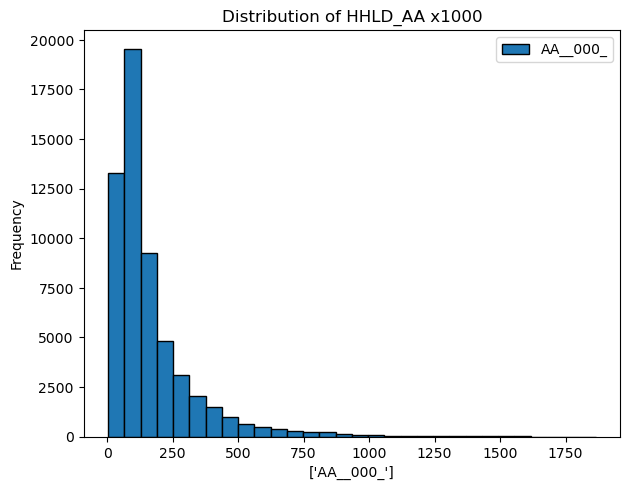

In [3]:
# View Target Distribution variable
df[target_variable].plot(kind='hist', bins=30, edgecolor='black')
plt.xlabel(target_variable)
plt.tight_layout()
plt.title("Distribution of HHLD_AA x1000")
plt.show()


No log-transforming of the target variable is necessary in Neural Network modeling

## 2. Feature Engineering

In [4]:
teams = np.unique(df['at'])  # 'at' means 'away_team', and 'ht' means 'home_team'

# integer encode teams
df, at_mapping = encode_categorical(df, 'at')  
df, ht_mapping = encode_categorical(df, 'ht')  # depends on the order teams happen to appear in the db, handled below
df, window_mappinng = encode_categorical(df, 'window')
df, market_mapping = encode_categorical(df, 'Market_abrev')

# Force ht_code to use the same encoding as at_code
at_inv = {team: code for code, team in at_mapping.items()}
df['ht_code'] = df['ht'].map(at_inv)  # overwrite ht_code column by re-encoding every home team using the away teams number scheme


In [5]:
# create matchup strings
# this feature is designed to capture any residual effect two teams have together that is not captured from the sum of their parts. (rivalries)
# note that we only capture this for division opponents - they play twice annually - this ensures there is enough data to potentially capture a signal
# there may be rivalries with non-division opponents but there is likely not enough data to capture a signal. 

matchup_string = []
for i in range(df.shape[0]):
    at = df['at'][i]
    ht = df['ht'][i]
    _, yn, _ = isdivision([at, ht])
    at_idx = teams.tolist().index(at)
    ht_idx = teams.tolist().index(ht)

    # take care to encode div matchups of t1@t2 and t2@t1 the same. 
    if at_idx < ht_idx:
        first_team = at
        second_team = ht
    else:
        first_team = ht
        second_team = at
    if yn == 1:
        matchup_string.append(f"{first_team}_{second_team}")
    else:
        matchup_string.append("Other")

In [6]:
# # Insert the div_matchup column into the dataframe
# insert_pos = df.columns.get_loc('ht') + 1
# df.insert(insert_pos, 'div_matchup', matchup_string)
'''this cell is skipped because our SQL workflow already engineered this feature'''


'this cell is skipped because our SQL workflow already engineered this feature'

In [7]:
# integer encode the division matchups
df, division_mapping = encode_categorical(df, 'div_matchup')

In [8]:
# build_concurrent_features is imported from the shared module, it captures the strength of viewership draw of matchups occuring concurrently.
df = build_concurrent_features(df)

In [9]:
# built_normalized_market_draw is imported from the shared module, captures home/away team's prior-year market avg normalized by that market's average draw
df = build_normalized_market_draw(df, 'AA__000_')

normalized_ht_market_draw:
count    42548.000000
mean         0.992272
std          0.367951
min          0.069906
25%          0.773809
50%          0.961828
75%          1.136732
max          2.833352
Name: normalized_ht_market_draw, dtype: float64
NaN count: 14681 (expected for Season 1 and pre-2014 rows)


In [10]:
## Only use years that have time series data available
df = df[df['Season'] > 2013]


In [11]:
## examine if any rows of the dataframe contain NAN
## evaluate Nans
predictors_target = df.columns.values.tolist() + target_variable
nan_cols = df[predictors_target].isna().any(axis=0).to_list()
np.unique(nan_cols)

array([False,  True])

In [12]:
## examine if any features in the dataset contain NAN (RTG feature not needed)
nan_idx = np.asarray([i for i, x in enumerate(nan_cols) if x])
nan_features = np.array(predictors_target)[nan_idx.astype(int)]
nan_features

array(['RTG'], dtype='<U32')

In [13]:
# ------------- cardinalities derived from encoded columns ----------------------
N_TEAMS        = int(df['at_code'].max()) + 1
N_MARKETS      = int(df['Market_abrev_code'].max()) + 1
N_WINDOWS      = int(df['window_code'].max()) + 1
N_DIV_MATCHUPS = int(df['div_matchup_code'].max()) + 1

# Embedding dimensions - rule of thumb: min(50, (cardinality + 1) // 2)
TEAM_EMBED_DIM   = min(50, (N_TEAMS + 1) // 2)   # 16
MARKET_EMBED_DIM = min(50, (N_MARKETS + 1) // 2)   # 28
NET_EMBED_DIM    = min(50, (N_WINDOWS + 1) // 2)   # ~5
DIV_EMBED_DIM    = 12   # hand-tuned; ~48 unique divisional matchup pairs

print(f'Teams:        {N_TEAMS:3d}   embed dim {TEAM_EMBED_DIM}')
print(f'Markets:      {N_MARKETS:3d}   embed dim {MARKET_EMBED_DIM}')
print(f'Networks:     {N_WINDOWS:3d}   embed dim {NET_EMBED_DIM}')
print(f'Div matchups: {N_DIV_MATCHUPS:3d}   embed dim {DIV_EMBED_DIM}')

Teams:         32   embed dim 16
Markets:       56   embed dim 28
Networks:       8   embed dim 4
Div matchups:  49   embed dim 12


## 1. An alternative to One-Hot Encoding

Other pipelines in this repo that attempt to derive signal from the ratings dataset choose to one-hot encode 32 teams as 32 binary columns and 32*56 Team_Market interactions as 1,792 sparse binary columns. This has two costs:

**Orthogonality:** every team is equidistant from every other team in the feature space.
The Cowboys and Patriots are as different as the Cowboys and the Jaguars. The model
cannot generalize: nothing it learns about nationally popular teams carries over between them.

**No information sharing across categories:** in OHE, the weight for "Patriots playing in Albuquerque" is estimated only from Patriots-in-Albuquerque rows (perhaps 4-5 games in 10 years of data). With embeddings, the Patriots vector is shaped by hundreds of Patriots games across all markets, and the Albuquerque vector by hundreds of games from many teams. In this way information is pooled (similar to partial pooling in probabilistic modeling): Patriots and Albuquerque each get their own embedding vectors, but the team vector is shaped by gradient updates from the appearances of all Patriot occurrences (against other teams) and the market vector shaped by all Albuquerque appearances (including other matchups). Their interaction pools information and generalizes naturally to sparse combinations.

**Sparsity:** One-Hot-Encoding 32 teams + 56 markets + matchup dummies, most of the feature columns
are zero for any given row. MLPs can struggle with sparse inputs.

> An **embedding** replaces each category with a small dense vector of learned real numbers.
Teams that behave similarly in the ratings data end up with similar vectors, not because
we told the model they're similar, but because it discovered that similarity from the target. (we will analyze with cosine similarity and 2D PCA visualization in the analysis section)

> Embeddings result in a much tighter model with far fewer modeling parameters when the data has high cardinality. This notebook will explore whether that compression results in increased learning from pooling information, or whether less parameters degrades the learning potential

In [14]:
# --------- 6. Data Assembly ----------------------------

# Index arrays for embedding lookups
home_teams   = df['ht_code'].values.astype(int)
away_teams   = df['at_code'].values.astype(int)
markets      = df['Market_abrev_code'].values.astype(int)
window_codes = df['window_code'].values.astype(int)
div_codes    = df['div_matchup_code'].values.astype(int)
ratings      = df['AA__000_'].values.astype(float)

# Train / val split - recompute after all preprocessing merges
train_mask_nn = (df['Date'] < '08-01-2024')  #| (df['Date'] > '08-01-2024')
tr = np.where( train_mask_nn.values)[0]
va = np.where(~train_mask_nn.values)[0]

# Continuous numerical features - fit scaler on train rows only
scaler_num = StandardScaler()
num_raw = df[predictors_numerical].values.astype(float)
scaler_num.fit(num_raw[tr])
num_scaled = scaler_num.transform(num_raw)    # (n, 37)

# OHE timeofday - 3 binary columns, fit on full df (all categories always present)
ohe_tod = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
tod_cols = ohe_tod.fit_transform(df[predictors_nominal]) # (n,  3)

# Boolean features - already 0/1, no scaling needed
bool_feats = df[predictors_bool].values.astype(float)  # (n,  1)

# Concurrent features - standardize continuous, leave flag as 0/1
conc_cont = df[['total_concurrent_popularity',
                'concurrent_count',
                'average_concurrent_popularity']].values.astype(float)
conc_flag = df[['above_19_flag']].values.astype(float)

scaler_conc = StandardScaler()
scaler_conc.fit(conc_cont[tr])
conc_scaled = scaler_conc.transform(conc_cont) # (n,  3)

# passthrough market _primary, _secondary features 
passthrough_feats = df[predictors_passthrough].values.astype(float)  # (n, 112)

# Final numericals matrix
numericals = np.hstack([num_scaled, tod_cols, bool_feats, conc_scaled, conc_flag, passthrough_feats]).astype(float)

print(f'numericals shape : {numericals.shape}')
print(f'Train rows       : {len(tr)}')
print(f'Val rows         : {len(va)}')
print(f'Ratings range    : [{ratings[tr].min():.1f}, {ratings[tr].max():.1f}]')

numericals shape : (42548, 167)
Train rows       : 38443
Val rows         : 4105
Ratings range    : [3.0, 1685.0]


In [15]:
df[predictors_passthrough].values.astype(float).shape

(42548, 112)

## 2. The Embedding Layer

An embedding layer is a matrix $E$ of shape `(cardinality, embed_dim)`. Each row is
the learned representation of one category.

**Forward pass** - a row lookup:
$$e_i = E[i, :]$$
For a batch of $m$ samples with indices $[i_1, i_2, \ldots, i_m]$:
$$\text{out} = E[\text{indices}] \quad \text{shape: } (m, d)$$
where d is embed_dim

**Backward pass** - scatter gradients back to the rows that were used:

Let $L = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2$ be the mean squared error loss over a batch of $m$ samples. Gradients are propagated layer by layer using the chain rule - each layer receives $\frac{\partial L}{\partial A^{[l]}}$ from the layer above and only needs to compute its local **Jacobian** (the matrix of partial derivatives of its outputs with respect to its inputs) to pass the gradient further back.

$$\frac{\partial L}{\partial E[k]} = \sum_{j : i_j = k} \frac{\partial L}{\partial e_{i_j}}$$

Only the rows that appeared in the forward pass receive a gradient. All other rows are
unchanged. The parameters in $E$ are updated the same way as MLP weights, by SGD or Adam.

**Why `np.add.at` and not `E[indices] += grad`:**
If the same category appears twice in a batch (e.g. Cowboys play twice), NumPy's `+=`
with repeated indices applies only the last gradient (a known Python/NumPy quirk).
`np.add.at` correctly accumulates gradients across all occurrences.

In [16]:
# ------- embedding layer -----------------------------------------

def init_embedding(cardinality, embed_dim):
    """
    Initialize an embedding table with scaled random values.
    Scale = sqrt(1/embed_dim): keeps initial embedding norms consistent
    regardless of dimension, similar in spirit to He initilization.

    Returns shape (cardinality, embed_dim).
    """
    scale = np.sqrt(2.0 / embed_dim)
    return np.random.randn(cardinality, embed_dim) * scale


def embedding_lookup(table, indices):
    """
    Forward pass: fetch embedding rows for a batch of integer indices.

    table:   shape (cardinality, embed_dim)
    indices: shape (m,) of integers in [0, cardinality)
    returns: shape (m, embed_dim)
    """
    return table[indices]


def embedding_backward(d_out, indices, table_shape):
    """
    Backward pass: scatter upstream gradients back to the embedding rows.

    d_out:       shape (m, embed_dim) - gradient from the layer above
    indices:     shape (m,) - which rows were looked up in the forward pass
    table_shape: (cardinality, embed_dim)

    Returns d_table of shape (cardinality, embed_dim).
    Only rows present in `indices` are non-zero.
    np.add.at handles repeated indices correctly (accumulates, not overwrites).
    """
    d_table = np.zeros(table_shape)
    np.add.at(d_table, indices, d_out)
    return d_table


# ----------------------- sanity check --------------------------------
np.random.seed(0)
table = init_embedding(cardinality=4, embed_dim=3)
indices = np.array([0, 2, 0])        # category 0 appears twice
out = embedding_lookup(table, indices)
print('Table:\n', table)
print('\nLookup for indices [0, 2, 0]:\n', out)

# Simulate upstream gradient of all ones
d_out  = np.ones_like(out)
d_tbl  = embedding_backward(d_out, indices, table.shape)
print('\nGradient table (row 0 should be 2x, row 2 should be 1x, rows 1&3 zero):')
print(d_tbl)

Table:
 [[ 1.44034271  0.32672699  0.79913622]
 [ 1.82968164  1.52485471 -0.79794405]
 [ 0.77574394 -0.12358264 -0.08427784]
 [ 0.33525227  0.11761108  1.18740935]]

Lookup for indices [0, 2, 0]:
 [[ 1.44034271  0.32672699  0.79913622]
 [ 0.77574394 -0.12358264 -0.08427784]
 [ 1.44034271  0.32672699  0.79913622]]

Gradient table (row 0 should be 2x, row 2 should be 1x, rows 1&3 zero):
[[2. 2. 2.]
 [0. 0. 0.]
 [1. 1. 1.]
 [0. 0. 0.]]


## 4. Assembling the Input Vector

The MLP input is built by concatenating embeddings, bilinear interaction scores,
and numerical features into a single dense vector per sample.

```
home_team       --> lookup(team_table)          shape (m, 16)
away_team       --> lookup(team_table)          shape (m, 16)
market          --> lookup(market_table)        shape (m, 28)
home_mkt_score  --> bilinear(home, W, market)   shape (m,  1)
away_mkt_score  --> bilinear(away, W, market)   shape (m,  1)
numericals      --> standardize                 shape (m,  k)
hstack all                                    shape (m, 62+k)
transpose for column-major MLP                shape (62+k, m)
```

### The Bilinear Interaction Matrix W

Concatenating team and market embeddings side-by-side lets the MLP combine them,
but only *implicitly* - the network has to discover team×market interactions across
layers. The **bilinear score** makes this interaction explicit:

$$\text{score}_{\text{home}} = e_{\text{home}} \cdot W \cdot e_{\text{market}}^\top$$

where $W$ has shape `(16, 28)`. Step by step:

1. $e_{\text{home}} \cdot W$ - projects the home team into market space, shape `(m, 28)`
2. element-wise multiply with $e_{\text{market}}$, then sum, one scalar per sample

The result answers: *"how compatible is this team with this market?"* The same $W$
is applied for the away team, giving two scalars appended to the input.

**Connection to linear model or model with full cardinality:** the linear model learned 32*56 = 1,792
independent team×market coefficients. The bilinear score produces the same matrix
approximately via a rank-16 factorization using only 16×28 = 448 parameters in W:

$$R_{\text{approx}} = E_{\text{team}} \cdot W \cdot E_{\text{market}}^\top \quad \text{shape } (32, 56)$$

**Backward pass through W**: four gradient paths from the chain rule, where $d_s = \frac{\partial L}{\partial s}$ is the upstream scalar gradient from the MLP:

$$\frac{\partial L}{\partial W} = e_{\text{home}}^\top (d_s \cdot e_{\text{market}}) + e_{\text{away}}^\top (d_s \cdot e_{\text{market}})$$

$$\frac{\partial L}{\partial e_{\text{home}}} \mathrel{+}= d_s \cdot e_{\text{market}} W^\top \qquad \frac{\partial L}{\partial e_{\text{away}}} \mathrel{+}= d_s \cdot e_{\text{market}} W^\top$$

$$\frac{\partial L}{\partial e_{\text{market}}} \mathrel{+}= d_s \cdot (e_{\text{home}} + e_{\text{away}}) W$$

The $\mathrel{+}=$ is critical: the bilinear path adds *on top of* the direct gradient
already flowing from each embedding's position in the concatenated input vector.

The **split offsets** dict tracks column boundaries in the hstacked matrix.
During backprop, `dX` is sliced at these boundaries and routed to the correct tables.
Numerical features need no scatter because their gradient flows through `dX` directly.

In [17]:
# ------------- input assembly and gradient splitting -------------------------------

def build_input(home_idx, away_idx, market_idx, window_idx, div_matchup_idx,
                numericals, team_table, market_table, window_table, div_matchup_table,
                W_interact, emb_keep_probs=None, training=False):
    """
    Assemble the MLP input from embeddings, bilinear scores, and numericals.

    home_idx, away_idx   : shape (m,) int, ht_code / at_code
    market_idx           : shape (m,) int, Market_abrev_code
    window_idx           : shape (m,) int, window_code
    div_matchup_idx      : shape (m,) int,div_matchup_code
    numericals           : shape (m, k) float, already standardized
    W_interact           : shape (TEAM_EMBED_DIM, MARKET_EMBED_DIM) - allows explicit interacion of team and market embeddings without leaving it to chance
                           W_interact is the learned projection between team and market spaces, trained alongside every other neuron
    emb_keep_probs       : dict with float keep-probabilities per entity, e.g.
                           {'home': 0.85, 'away': 0.85, 'market': 0.85}
                           None = no embedding dropout.
    training             : set False at validation/inference to disable dropout.

    Returns X (input_dim, m), offsets dict, cache_bx for bilinear backward.
    """
    e_home        = embedding_lookup(team_table,        home_idx)        # (m, 16)
    e_away        = embedding_lookup(team_table,        away_idx)        # (m, 16)
    e_market      = embedding_lookup(market_table,      market_idx)      # (m, 28)
    e_window      = embedding_lookup(window_table,      window_idx)      # (m,  5)
    e_div_matchup = embedding_lookup(div_matchup_table, div_matchup_idx) # (m, 12)

    m = home_idx.shape[0]

    # Embedding dropout: applied BEFORE bilinear calculation with W_interact so the cascade is consistent:
    # dropping home team zeros both e_home in X and home_mkt_score automatically.
    # Inverted scaling (divide by kp) preserves expected embedding magnitude so
    # no training/inference mismatch occurs.
    drop_masks = {}  # initialize dictionary to store dropout masks for each entity, we will need these masks later to properly backprop through the bilinear interaction scores in scatter_input_grad
    if training and emb_keep_probs is not None:
        for key, kp in emb_keep_probs.items():  # this is what makes the dropping independent, each entity (home, away, market) gets its own dropout mask
            mask = (np.random.rand(m) < kp) / kp   # 0 for dropped, 1/kp for surviving. This is the inverted dropout formula, applied per sample. 
            drop_masks[key] = mask                # save the mask for later use in scatter_input_grad
            if key == 'home':
                e_home = e_home * mask[:, np.newaxis]  # e_home is shape (m, 16), mask is shape (m,), we need to add a new axis to broadcast correctly across the embedding dimension
            elif key == 'away':
                e_away = e_away * mask[:, np.newaxis]  # the entire row is either zeroed out (dropped) or scaled up uniformily. This is row-level dropout, not neuron-level dropout. We don't want to drop just part of the embedding for a given sample, we want to drop the entire embedding for that sample to ensure the model learns to not rely on any single entity too heavily.
            elif key == 'market':
                e_market = e_market * mask[:, np.newaxis]

    # dropout before this section is deliberate. A zeroed e_home automatically produces a zero home_mkt_score, so the model learns to rely on the market embedding alone in those cases, and vice versa. If we were to apply dropout after bilinear(), the model could still rely on e_home for the home_mkt_score even when the home team is dropped, which would create an inconsistent cascade and reduce the regularization effect of dropout.
    temp_home = e_home @ W_interact                                      # (m, 28)
    temp_away = e_away @ W_interact                                      # (m, 28)
    home_mkt_score = np.sum(temp_home * e_market, axis=1, keepdims=True) # (m,  1)  how much does the home team draw in this specific market
    away_mkt_score = np.sum(temp_away * e_market, axis=1, keepdims=True) # (m,  1)  how much does the away team draw in this specific market

    cache_bx = {
        'e_home': e_home, 'e_away': e_away, 'e_market': e_market,
        'temp_home': temp_home, 'temp_away': temp_away,
        'drop_masks': drop_masks,   # stored for scatter_input_grad
    }

    # Build offsets with a running pointer so additions never go out of sync
    d_t, d_m = team_table.shape[1], market_table.shape[1]
    d_w, d_d = window_table.shape[1], div_matchup_table.shape[1]
    pos = 0
    offsets = {}  # dictionary that tracks where each component sits in the concatenated X_row, we will need this map later to index our gradients correctly during back propogation
    offsets['home']           = (pos, pos + d_t);              pos += d_t
    offsets['away']           = (pos, pos + d_t);              pos += d_t
    offsets['market']         = (pos, pos + d_m);              pos += d_m
    offsets['home_mkt_score'] = (pos, pos + 1);                pos += 1
    offsets['away_mkt_score'] = (pos, pos + 1);                pos += 1
    offsets['window']         = (pos, pos + d_w);              pos += d_w
    offsets['div_matchup']    = (pos, pos + d_d);              pos += d_d
    offsets['numerical']      = (pos, pos + numericals.shape[1])

    X_row = np.hstack([e_home, e_away, e_market,
                       home_mkt_score, away_mkt_score,
                       e_window, e_div_matchup, numericals])
    return X_row.T, offsets, cache_bx   # (input_dim, m)


def bilinear_backward(d_score_home, d_score_away, cache_bx, W_interact):
    """
    Backward pass through the two bilinear interaction scores. backprop gives us d_score_home
    and d_score_away - the gradient of the loss flowing back through those two scalars. We 
    need to distribute that into gradients for W_interact, e_home, e_away, and e_market.

    d_score_home, d_score_away : shape (m, 1) - upstream gradients from dX
    cache_bx   : dict from build_input - e_home, e_away, e_market, temp_home, temp_away
    W_interact : shape (TEAM_EMBED_DIM, MARKET_EMBED_DIM)

    Returns dW, d_home_extra, d_away_extra, d_market_extra.
    """
    e_home    = cache_bx['e_home']
    e_away    = cache_bx['e_away']
    e_market  = cache_bx['e_market']
    temp_home = cache_bx['temp_home']
    temp_away = cache_bx['temp_away']

    dW = (e_home.T @ (d_score_home * e_market)
        + e_away.T @ (d_score_away * e_market))               # (16, 28)

    d_home_extra   = (d_score_home * e_market) @ W_interact.T  # (m, 16) - additional gradient into embedding, on top of the direct gradient from their contribution to dX
    d_away_extra   = (d_score_away * e_market) @ W_interact.T  # (m, 16)
    d_market_extra = (d_score_home * temp_home
                    + d_score_away * temp_away)                 # (m, 28)

    return dW, d_home_extra, d_away_extra, d_market_extra


def scatter_input_grad(dX, offsets, cache_bx, W_interact,
                       home_idx, away_idx, market_idx, window_idx, div_matchup_idx,
                       team_table, market_table, window_table, div_matchup_table):
    """
    Reverse of build_input: 
    
    1) use offsets to slice dX back into pieces (reverse the concatenation in build_input)
    2) run bilinear_backward() to get the extra gradient contibutions
    3) apply embedding drop masks (if any) to zero out gradients for dropped samples
    4) scatter all gradients into the embedding tables.

    Returns d_team_table, d_market_table, d_window_table, d_div_matchup_table, dW.
    """
    dX_row = dX.T   # (m, input_dim)

    d_home     = dX_row[:, offsets['home'][0]           : offsets['home'][1]]
    d_away     = dX_row[:, offsets['away'][0]           : offsets['away'][1]]
    d_market_g = dX_row[:, offsets['market'][0]         : offsets['market'][1]]
    d_score_hm = dX_row[:, offsets['home_mkt_score'][0] : offsets['home_mkt_score'][1]]
    d_score_am = dX_row[:, offsets['away_mkt_score'][0] : offsets['away_mkt_score'][1]]
    d_window_g = dX_row[:, offsets['window'][0]         : offsets['window'][1]]
    d_div_g    = dX_row[:, offsets['div_matchup'][0]    : offsets['div_matchup'][1]]

    dW, d_home_extra, d_away_extra, d_market_extra = bilinear_backward(
        d_score_hm, d_score_am, cache_bx, W_interact
    )

    # Apply drop masks: converts gradient w.r.t. post-drop embedding into gradient
    # w.r.t. the embedding table rows.  Dropped samples get zero gradient.
    # Surviving samples get gradient scaled by 1/kp (matches forward-pass scaling).
    drop_masks = cache_bx.get('drop_masks', {})

    d_home_grad = d_home + d_home_extra
    if 'home' in drop_masks:
        d_home_grad = d_home_grad * drop_masks['home'][:, np.newaxis]

    d_away_grad = d_away + d_away_extra
    if 'away' in drop_masks:
        d_away_grad = d_away_grad * drop_masks['away'][:, np.newaxis]

    d_market_grad = d_market_g + d_market_extra
    if 'market' in drop_masks:
        d_market_grad = d_market_grad * drop_masks['market'][:, np.newaxis]


    d_team_table = np.zeros_like(team_table)
    np.add.at(d_team_table, home_idx, d_home_grad)
    np.add.at(d_team_table, away_idx, d_away_grad)

    d_market_table    = embedding_backward(d_market_grad,  market_idx,      market_table.shape)
    d_window_table    = embedding_backward(d_window_g,     window_idx,      window_table.shape)
    d_div_matchup_tbl = embedding_backward(d_div_g,        div_matchup_idx, div_matchup_table.shape)

    return d_team_table, d_market_table, d_window_table, d_div_matchup_tbl, dW

## 4a. Embedding Dropout

Embedding dropout is an optional regularization technique applied inside `build_input()` - before the bilinear interaction and before the MLP ever runs.

### Why embedding dropout instead of hidden-layer dropout

The dominant learnable parameters in this model are the entity embedding tables (team: 32×16, market: 56×28), not the small MLP layers ([136 --> 80 --> 40 -- >1]). The primary overfitting risk is that individual team and market vectors memorize historical patterns rather than learning generalizable representations. Applying dropout to the hidden layers ([80, 40] neurons) leaves the embeddings unconstrained and misses the actual source of variance. Embedding dropout forces the model to sometimes predict without a specific team or market's vector, requiring it to fall back on numerical features (win totals, playoff odds, schedule features) rather than relying on memorized entity identity.

### What row-level dropout means

Standard neuron dropout zeroes individual elements of an activation vector. Embedding dropout zeroes an entire row (the full 16-dim home team vector), for a randomly selected subset of samples in a batch. Mathematically, for a batch of $m$ games and an embedding lookup $e \in \mathbb{R}^{m \times d}$:

$$\tilde{e}_i = \begin{cases} 0 & \text{with probability } 1 - k_p \\ e_i & \text{with probability } k_p \end{cases}$$

Dropping an entire row is appropriate here because the embedding represents a single entity (a team or market). There is no meaningful interpretation of zeroing half the dimensions of a team vector. That would corrupt the geometric structure of the embedding space.

### Inverted scaling

Without correction, the expected magnitude of a dropped embedding is $k_p \cdot \|e\|$ instead of $\|e\|$. At inference (no dropout), the full embedding is always present, causing a systematic mismatch: the network was calibrated on inputs that were on average $k_p$ times smaller than what it receives at test time. Inverted scaling fixes this by dividing surviving rows by $k_p$:

$$\tilde{e}_i = \begin{cases} 0 & \text{with probability } 1 - k_p \\ e_i / k_p & \text{with probability } k_p \end{cases}$$

Expected value: $k_p \cdot (e_i / k_p) + (1 - k_p) \cdot 0 = e_i$

Training and inference now operate on the same expected magnitudes. No rescaling is necessary at inference.

This also preserves the expected bilinear interaction score. If home survives with probability $k_h$ and market with probability $k_m$, independently:

$$\mathbb{E}[\widetilde{e}_{\mathrm{home}}^\top W \widetilde{e}_{\mathrm{market}}] = k_h k_m \cdot \frac{e_h^\top W e_m}{k_h k_m} = e_h^\top W e_m$$

### Independent dropping per entity

Home team, away team, and market embeddings each receive their own per-sample random mask. A given game might have its home team dropped but its market intact, or vice versa. This is strictly more powerful than joint dropping because it exposes the model to many more partial-information combinations, forcing each entity's embedding to carry stand-alone signal rather than relying on co-occurrence with other entities.

Window and `div_matchup` embeddings are not dropped. Their small dimensionality (5 and 12) and low cardinality make dropping them noisy without regularization benefit.

### Chain rule through dropout (backward pass)

The dropout operation is $\tilde{e} = e \odot m$ where $m_i \in \{0,\, 1/k_p\}$. By the chain rule:

$$\frac{\partial \mathcal{L}}{\partial e_i} = \frac{\partial \mathcal{L}}{\partial \tilde{e}_i} \cdot m_i$$

`scatter_input_grad` applies the same mask to the combined gradient (direct path & bilinear path) before scattering into the embedding tables. Dropped samples contribute zero gradient therefore the embedding table row for that entity is not updated from that sample. Surviving samples' gradients are scaled by $1/k_p$, matching the forward-pass scaling.

`bilinear_backward()` requires no changes: it reads the post-drop embeddings from `cache_bx`, so dropped rows already contribute zero to $\partial W_{\mathrm{interact}}$ automatically through the chain rule.

### Hyperparameters

```python
emb_keep_probs = {'home': 0.85, 'away': 0.85, 'market': 0.85}
```

Start at 0.85 (15% drop rate). The small architecture and information-dense embeddings (16 dimensions for 32 teams) mean aggressive rates destroy signal faster than they regularize. When adjusting, the market embedding (28-dim, 56 entities) can tolerate slightly more aggressive dropping than team if tuning independently.

Note: `MLP_tv_ratings.ipynb` applies dropout to hidden neuron activations after each
layer. Here dropout is applied at the input representation level, entire embedding
rows are zeroed, not individual neurons. This targets the primary overfitting risk
(memorized entity patterns) rather than the MLP layers themselves.

## 6. MLP Functions

The core MLP functions (`forward_prop`, `back_prop`, `relu`, Adam) are identical to those
in `MLP_tv_ratings.ipynb` and are imported from `MLP_core.py`. See that notebook for
full mathematical derivations. One difference: `forward_prop` is called here WITHOUT
hidden-layer dropout kwargs, embedding dropout (above) is the regularization strategy
for this model, applied before the MLP rather than within it.

In [18]:
# --------------- embedding-specific optimizer functions ---------------------

def init_embed_adam(shape):
    """Zero-initialize Adam moments for one embedding table or W_interact."""
    return {'m': np.zeros(shape), 'v': np.zeros(shape)}

def update_embed_adam(table, d_table, state, alpha, t,
                      beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Dense Adam update for an embedding table or W_interact.

    Rows absent from the current mini-batch have d_table=0, so their moments
    decay toward zero rather than receiving a phantom update - an acceptable
    approximation given that all 32 teams and most markets appear in every
    batch of 272 NFL games.
    """
    state['m'] = beta1 * state['m'] + (1 - beta1) * d_table
    state['v'] = beta2 * state['v'] + (1 - beta2) * d_table ** 2
    m_hat = state['m'] / (1 - beta1 ** t)
    v_hat = state['v'] / (1 - beta2 ** t)
    table -= alpha * m_hat / (np.sqrt(v_hat) + eps)
    return table, state

def update_embedding_tables(team_table, market_table, window_table, div_matchup_table,
                            d_team, d_market, d_window, d_div_matchup, alpha):
    """SGD update for all embedding tables, kept for debugging / ablation."""
    team_table        -= alpha * d_team
    market_table      -= alpha * d_market
    window_table      -= alpha * d_window
    div_matchup_table -= alpha * d_div_matchup
    return team_table, market_table, window_table, div_matchup_table

## 7. Training Loop

The training loop adds three steps relative to the MNIST loop:

1. **`build_input`** before the forward pass - assembles embeddings + bilinear scores
   + numericals into X; also returns `cache_bx` with intermediate values needed for
   the bilinear backward pass
2. **`scatter_input_grad`** after backprop - slices `dX`, calls `bilinear_backward`,
   and accumulates all gradients (direct + via W) into the embedding tables;
   returns `dW` for the interaction matrix
3. **`W_interact -= alpha * dW`** - updates the bilinear bridge matrix alongside
   the embedding tables each iteration

Early stopping saves and restores `params`, `team_table`, `market_table`, and
`W_interact` together as a single consistent best state.

Input dim : 245  |  MLP params: 39,809
Epoch    0 | train R2: -0.4821 | val R2: 0.6112
Epoch   10 | train R2: 0.8761 | val R2: 0.8634
Epoch   20 | train R2: 0.9098 | val R2: 0.8890
Epoch   30 | train R2: 0.9188 | val R2: 0.9001
Epoch   40 | train R2: 0.9259 | val R2: 0.9061
Epoch   50 | train R2: 0.9311 | val R2: 0.9034
Epoch   60 | train R2: 0.9331 | val R2: 0.8951
Epoch   70 | train R2: 0.9392 | val R2: 0.9056
Epoch   80 | train R2: 0.9426 | val R2: 0.9041
Epoch   90 | train R2: 0.9434 | val R2: 0.9032
Epoch  100 | train R2: 0.9468 | val R2: 0.8988
Epoch  110 | train R2: 0.9499 | val R2: 0.8985

Early stopping at epoch 118. Best val R2: 0.9062


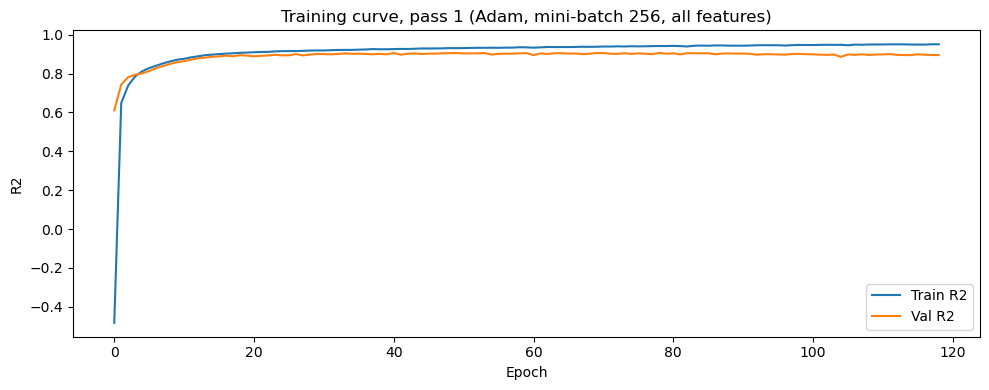

In [19]:
# ------------ network config ------------------------------------------
N_NUMERICAL = numericals.shape[1]
INPUT_DIM = (TEAM_EMBED_DIM * 2 + MARKET_EMBED_DIM + 2
               + NET_EMBED_DIM + DIV_EMBED_DIM + N_NUMERICAL)
layer_dims = [INPUT_DIM, 128, 64, 1]

alpha      = 0.0005   # Adam default learning rate
beta1      = 0.9
beta2      = 0.999
eps_adam   = 1e-8
n_epochs   = 1000
batch_size = 256
patience   = 40  # early stopping patience in epochs

emb_dropout    = True
emb_keep_probs = {'home': 0.75, 'away': 0.75, 'market': 0.65}  # Dropout regularization percentages (market dimension is larger and can handle more dropout)

# ------------ initialize ---------------------------------------------------
np.random.seed(42)
team_table        = init_embedding(N_TEAMS,        TEAM_EMBED_DIM)
market_table      = init_embedding(N_MARKETS,      MARKET_EMBED_DIM)
window_table      = init_embedding(N_WINDOWS,      NET_EMBED_DIM)
div_matchup_table = init_embedding(N_DIV_MATCHUPS, DIV_EMBED_DIM)
W_interact        = init_embedding(TEAM_EMBED_DIM, MARKET_EMBED_DIM)
params            = init_params(layer_dims, strategy='he')

adam_params  = init_adam_state(params)
adam_team    = init_embed_adam(team_table.shape)
adam_market  = init_embed_adam(market_table.shape)
adam_window  = init_embed_adam(window_table.shape)
adam_div     = init_embed_adam(div_matchup_table.shape)
adam_W       = init_embed_adam(W_interact.shape)

# -- precompute target variance for R2 conversion --
var_tr = float(np.var(ratings[tr]))
var_va = float(np.var(ratings[va]))

print(f'Input dim : {INPUT_DIM}  |  MLP params: {sum(v.size for v in params.values()):,}')

# ------------ training loop (mini-batch Adam) ------------------------------
tr_losses, va_losses = [], []
tr_r2s,    va_r2s   = [], []
best_val, best_state = np.inf, None
no_improve = 0
t = 0   # global Adam step counter, incremented once per mini-batch

for epoch in range(n_epochs):
    perm = np.random.permutation(tr)
    batch_losses = []

    for start in range(0, len(perm), batch_size):
        batch = perm[start : start + batch_size]
        t    += 1

        # -- forward --------------------------------------------------------
        X_b, offsets, cache_bx = build_input(
            home_teams[batch], away_teams[batch], markets[batch],
            window_codes[batch], div_codes[batch],
            numericals[batch], team_table, market_table,
            window_table, div_matchup_table, W_interact,
            emb_keep_probs=emb_keep_probs if emb_dropout else None,
            training=True
        )
        AL, caches = forward_prop(X_b, params, output_activation='linear')
        batch_losses.append(mse_loss(AL, ratings[batch]))

        # -- backward -------------------------------------------------------
        grads, dX = back_prop(AL, ratings[batch], caches, params)
        params, adam_params = update_params_adam(
            params, grads, adam_params, alpha, t, beta1, beta2, eps_adam
        )

        d_team, d_market, d_window, d_div, dW = scatter_input_grad(
            dX, offsets, cache_bx, W_interact,
            home_teams[batch], away_teams[batch], markets[batch],
            window_codes[batch], div_codes[batch],
            team_table, market_table, window_table, div_matchup_table
        )
        team_table,        adam_team   = update_embed_adam(team_table,        d_team,   adam_team,   alpha, t, beta1, beta2, eps_adam)
        market_table,      adam_market = update_embed_adam(market_table,      d_market, adam_market, alpha, t, beta1, beta2, eps_adam)
        window_table,      adam_window = update_embed_adam(window_table,      d_window, adam_window, alpha, t, beta1, beta2, eps_adam)
        div_matchup_table, adam_div    = update_embed_adam(div_matchup_table, d_div,    adam_div,    alpha, t, beta1, beta2, eps_adam)
        W_interact,        adam_W      = update_embed_adam(W_interact,        dW,       adam_W,      alpha, t, beta1, beta2, eps_adam)

    # -- end-of-epoch validation --------------------------------------------
    loss_tr = float(np.mean(batch_losses))
    X_va, _, _ = build_input(  # comes only from validation data
        home_teams[va], away_teams[va], markets[va],
        window_codes[va], div_codes[va],
        numericals[va], team_table, market_table,
        window_table, div_matchup_table, W_interact,
        emb_keep_probs=None, training=False
    )
    AL_va, _ = forward_prop(X_va, params, output_activation='linear')
    loss_va   = mse_loss(AL_va, ratings[va])

    r2_tr = 1 - loss_tr / var_tr
    r2_va = 1 - loss_va / var_va

    tr_losses.append(loss_tr)
    va_losses.append(loss_va)
    tr_r2s.append(r2_tr);       va_r2s.append(r2_va)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:4d} | train R2: {r2_tr:.4f} | val R2: {r2_va:.4f}')

    if loss_va < best_val:
        best_val   = loss_va
        best_state = {
            'params':            {k: v.copy() for k, v in params.items()},
            'team_table':        team_table.copy(),
            'market_table':      market_table.copy(),
            'window_table':      window_table.copy(),
            'div_matchup_table': div_matchup_table.copy(),
            'W_interact':        W_interact.copy(),
        }
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val R2: {1 - best_val / var_va:.4f}')
            break

# ------------ restore best -------------------------------------------------
params, team_table, market_table, window_table, div_matchup_table, W_interact = (
    best_state['params'],
    best_state['team_table'],
    best_state['market_table'],
    best_state['window_table'],
    best_state['div_matchup_table'],
    best_state['W_interact'],
)

plt.figure(figsize=(10, 4))
plt.plot(tr_r2s, label='Train R2')
plt.plot(va_r2s, label='Val R2')
plt.xlabel('Epoch')
plt.ylabel('R2')
plt.title('Training curve, pass 1 (Adam, mini-batch 256, all features)')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Permutation Importance (Feature Selection/Pruning)

This algorithm is shared with `MLP_tv_ratings.ipynb`, see that notebook for the full derivation.
Feature groups below reflect the embedding architecture: home team, away team, market,
window, div_matchup as index-permutation groups; numerical features as individual columns.

Baseline val MSE : 1535.2027


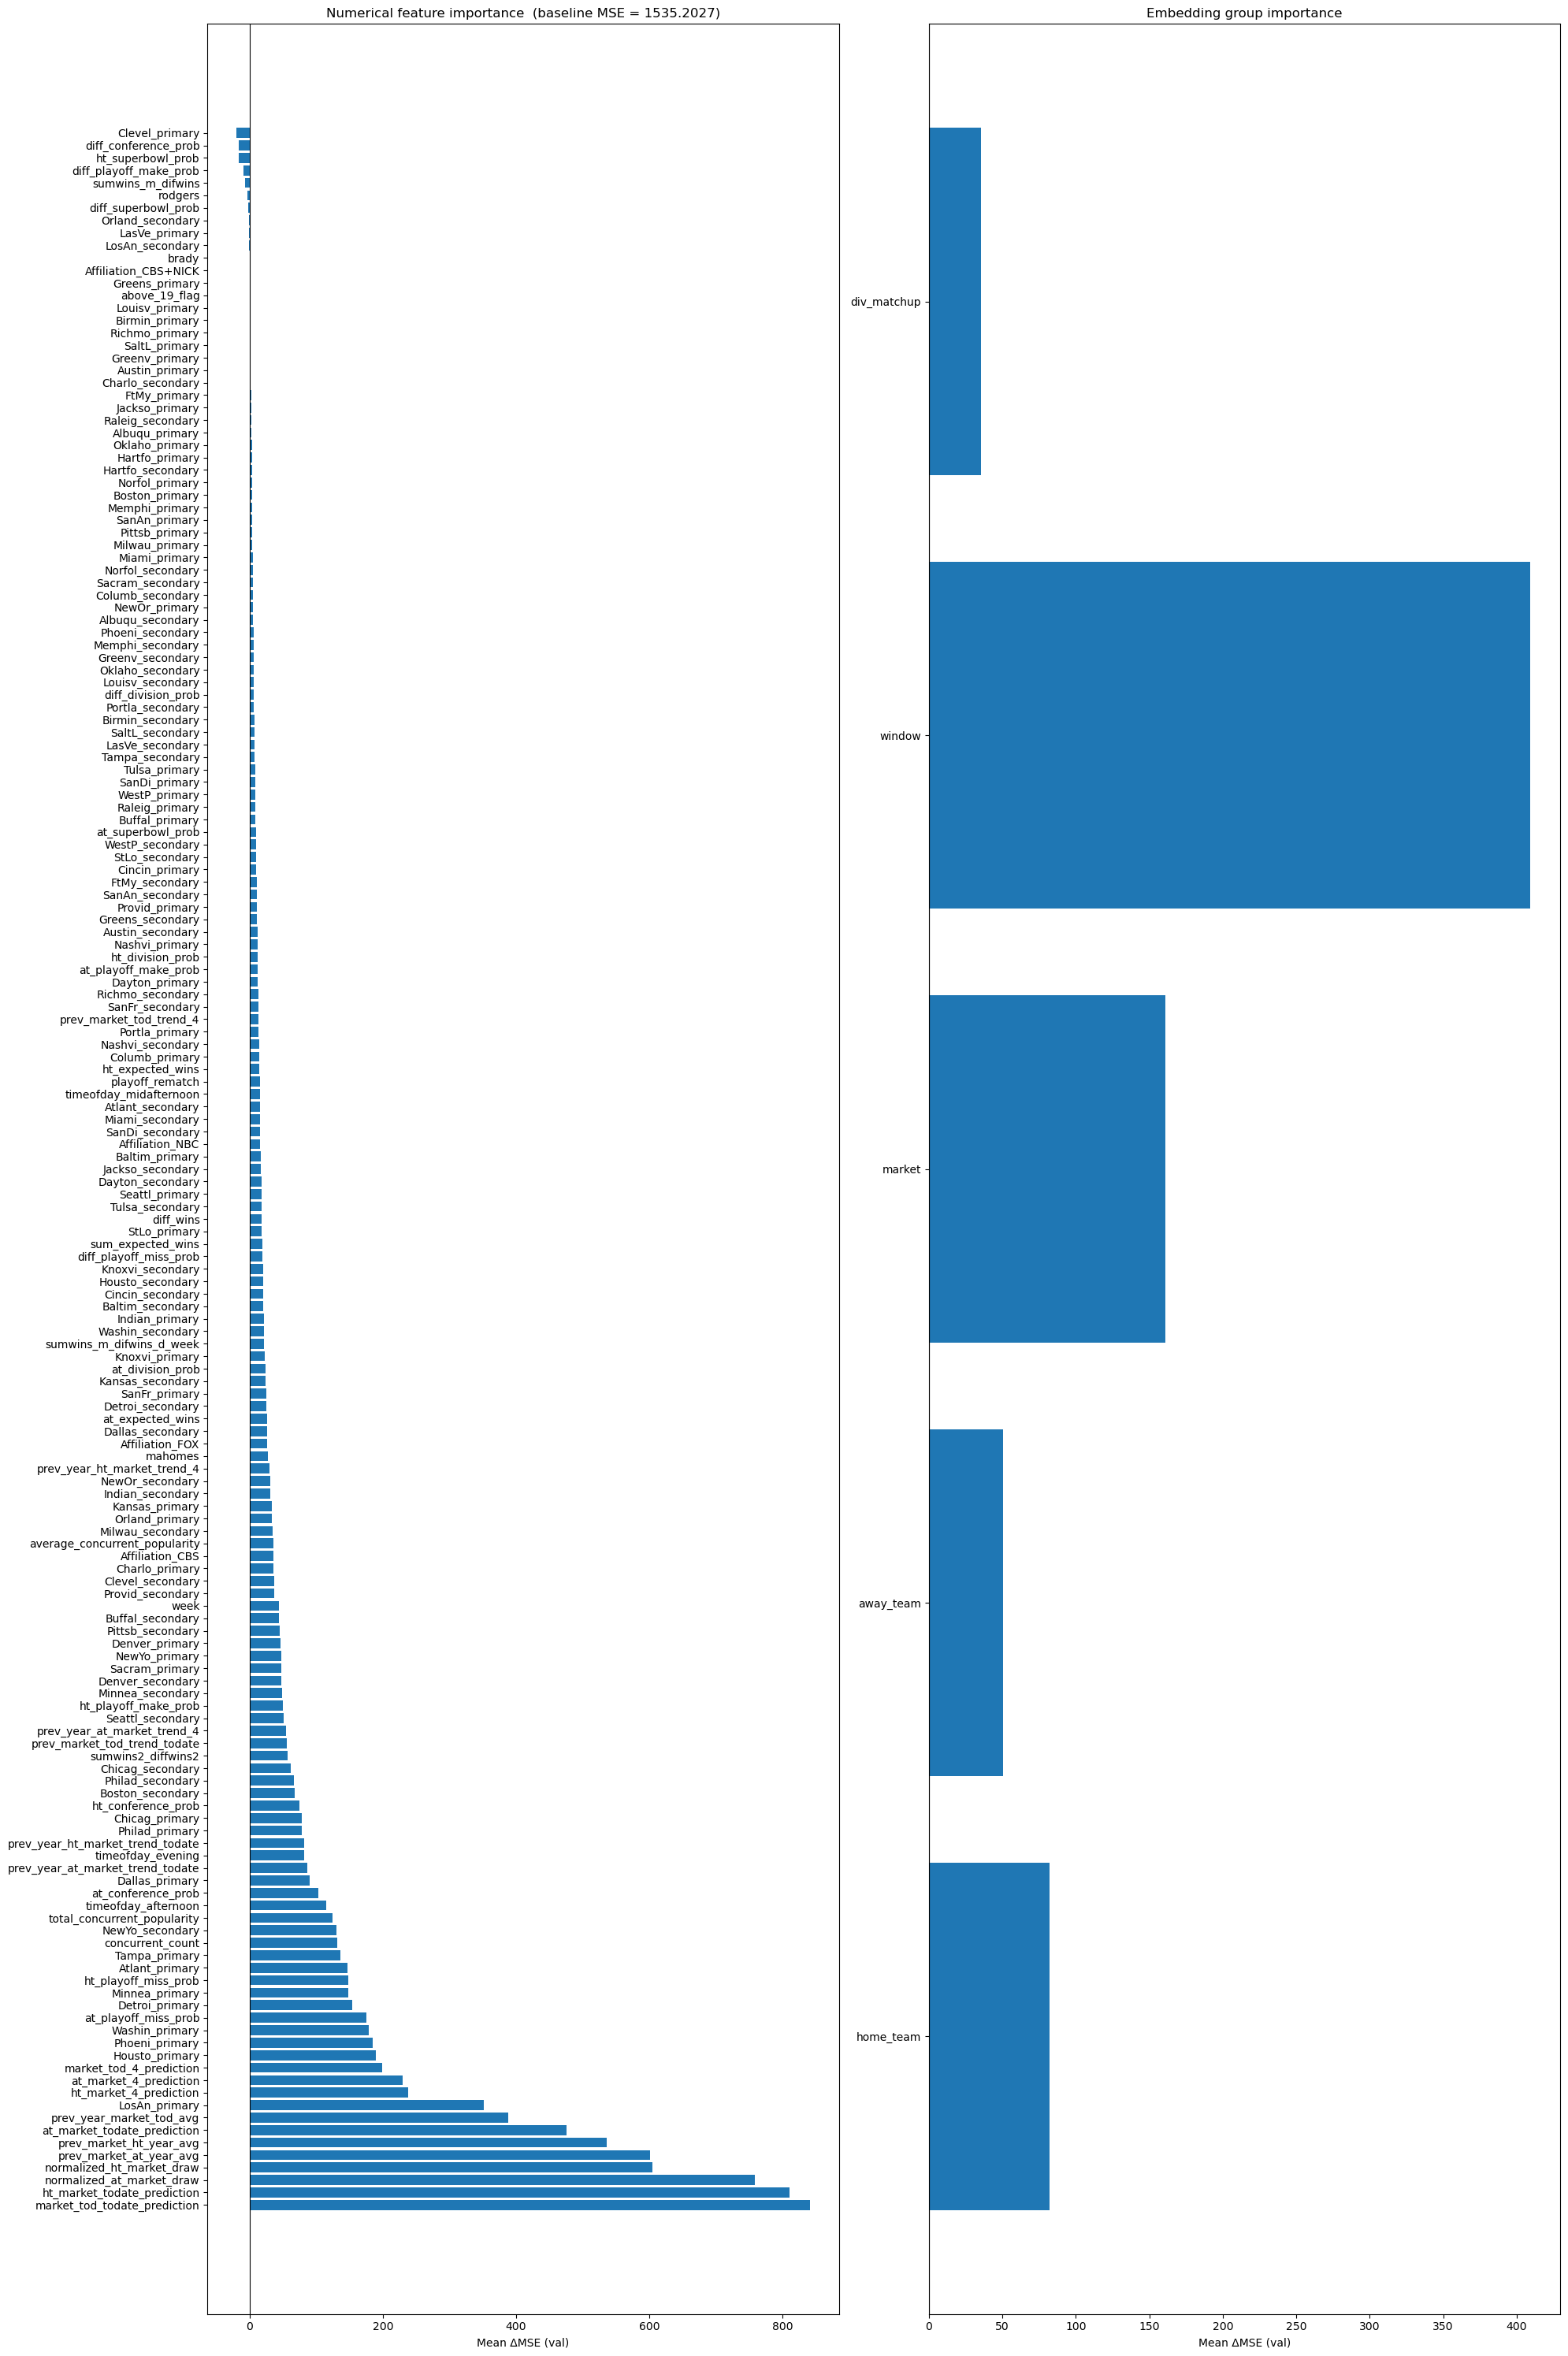


Raw ΔMSE by numerical feature (descending):
  market_tod_todate_prediction                   Δ = +841.1896
  ht_market_todate_prediction                    Δ = +810.1499
  normalized_at_market_draw                      Δ = +758.0216
  normalized_ht_market_draw                      Δ = +605.0695
  prev_market_at_year_avg                        Δ = +600.7037
  prev_market_ht_year_avg                        Δ = +535.4519
  at_market_todate_prediction                    Δ = +476.0220
  prev_year_market_tod_avg                       Δ = +388.0823
  LosAn_primary                                  Δ = +351.9076
  ht_market_4_prediction                         Δ = +237.8252
  at_market_4_prediction                         Δ = +229.6349
  market_tod_4_prediction                        Δ = +198.4259
  Housto_primary                                 Δ = +189.3276
  Phoeni_primary                                 Δ = +184.4655
  Washin_primary                                 Δ = +178.4522
  at_playo

In [20]:
# -- 9. Permutation Importance ------------------------------------------------
N_REPEATS = 5

# baseline val MSE with the trained model
X_va_base, _, _ = build_input(
    home_teams[va], away_teams[va], markets[va],
    window_codes[va], div_codes[va],
    numericals[va], team_table, market_table,
    window_table, div_matchup_table, W_interact
)
AL_base, _ = forward_prop(X_va_base, params, output_activation='linear')
L_base      = mse_loss(AL_base, ratings[va])
print(f'Baseline val MSE : {L_base:.4f}')

# -- numerical feature permutation ---------------------------------------------
tod_feature_names = ohe_tod.get_feature_names_out(predictors_nominal).tolist()
feature_names = (predictors_numerical
               + tod_feature_names
               + predictors_bool
               + ['total_concurrent_popularity', 'concurrent_count',
                  'average_concurrent_popularity', 'above_19_flag']
               + predictors_passthrough)

n_features = numericals.shape[1]
assert len(feature_names) == n_features, \
    f'Name count {len(feature_names)} != column count {n_features}'

num_va = numericals[va].copy()
deltas = np.zeros(n_features)

for j in range(n_features):
    rep_deltas = []
    for _ in range(N_REPEATS):
        perm_va       = num_va.copy()
        perm_va[:, j] = np.random.permutation(perm_va[:, j])
        X_perm, _, _  = build_input(
            home_teams[va], away_teams[va], markets[va],
            window_codes[va], div_codes[va],
            perm_va, team_table, market_table,
            window_table, div_matchup_table, W_interact
        )
        AL_perm, _    = forward_prop(X_perm, params, output_activation='linear')
        rep_deltas.append(mse_loss(AL_perm, ratings[va]) - L_base)
    deltas[j] = np.mean(rep_deltas)

# ------------ Group permutation --------------------------------------
embed_group_names = ['home_team', 'away_team', 'market', 'window', 'div_matchup']
embed_deltas      = {}

for name in embed_group_names:
    rep_deltas = []
    for _ in range(N_REPEATS):
        h  = np.random.permutation(home_teams[va])   if name == 'home_team'   else home_teams[va]
        aw = np.random.permutation(away_teams[va])   if name == 'away_team'   else away_teams[va]
        mk = np.random.permutation(markets[va])      if name == 'market'      else markets[va]
        wn = np.random.permutation(window_codes[va]) if name == 'window'      else window_codes[va]
        dv = np.random.permutation(div_codes[va])    if name == 'div_matchup' else div_codes[va]
        X_perm, _, _ = build_input(
            h, aw, mk, wn, dv,
            num_va, team_table, market_table,
            window_table, div_matchup_table, W_interact
        )
        AL_perm, _ = forward_prop(X_perm, params, output_activation='linear')
        rep_deltas.append(mse_loss(AL_perm, ratings[va]) - L_base)
    embed_deltas[name] = np.mean(rep_deltas)

# ----------------- Plot --------------------------------------------
order = np.argsort(deltas)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(20, 30))

axes[0].barh([feature_names[i] for i in order], deltas[order])
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].set_xlabel('Mean \u0394MSE (val)')
axes[0].set_title(f'Numerical feature importance  (baseline MSE = {L_base:.4f})')

axes[1].barh(embed_group_names, [embed_deltas[n] for n in embed_group_names])
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_xlabel('Mean \u0394MSE (val)')
axes[1].set_title('Embedding group importance')

plt.tight_layout()
plt.show()

print('\nRaw \u0394MSE by numerical feature (descending):')
for i in order:
    print(f'  {feature_names[i]:<45s}  \u0394 = {deltas[i]:+.4f}')

In [21]:
# --------- 10. Final Training: trimmed feature set -------------------------------
# Run this cell after reviewing permutation importance above.
# Adjust threshold, then rerun to change which features are kept.
threshold = 0.0001 * L_base   # 1% of baseline val MSE, tune as needed

keep_mask = deltas >= threshold
keep_cols = list(np.where(keep_mask)[0])

# Override: features with temporal importance (active during training, rare in val window)
# are kept regardless of their permutation importance score on the val set.
# Example: brady was active 2001-2022, real signal in training but zero val-set importance.
ALWAYS_KEEP_DENSE = ['brady', 'rodgers', 'mahomes']  # e.g. ['brady', 'rodgers', 'mahomes']
always_keep_indices = [i for i, n in enumerate(feature_names) if n in ALWAYS_KEEP_DENSE]
keep_cols = sorted(set(keep_cols) | set(always_keep_indices))

numericals_trim  = numericals[:, keep_cols]
N_NUM_TRIM       = numericals_trim.shape[1]
INPUT_DIM_TRIM   = (TEAM_EMBED_DIM * 2 + MARKET_EMBED_DIM + 2
                    + NET_EMBED_DIM + DIV_EMBED_DIM + N_NUM_TRIM)
# layer_dims_trim  = [INPUT_DIM_TRIM, 80, 40, 1]
layer_dims.remove(INPUT_DIM)
layer_dims_trim = [INPUT_DIM_TRIM] + layer_dims

print(f'Features kept : {N_NUM_TRIM} / {N_NUMERICAL}')
print(f'Dropped       : {[feature_names[j] for j in np.where(~keep_mask)[0] if feature_names[j] not in ALWAYS_KEEP_DENSE]}')
print(f'Input dim     : {INPUT_DIM_TRIM}')
if ALWAYS_KEEP_DENSE:
    print(f'Force-kept (ALWAYS_KEEP_DENSE override) : {[n for n in ALWAYS_KEEP_DENSE if n in feature_names]}')

Features kept : 156 / 167
Dropped       : ['sumwins_m_difwins', 'ht_superbowl_prob', 'diff_playoff_make_prob', 'diff_conference_prob', 'diff_superbowl_prob', 'Affiliation_CBS+NICK', 'Clevel_primary', 'Greens_primary', 'LasVe_primary', 'LosAn_secondary', 'Orland_secondary']
Input dim     : 234
Force-kept (ALWAYS_KEEP_DENSE override) : ['brady', 'rodgers', 'mahomes']


## 9. Final Training (Trimmed Features)

Epoch    0 | train R2: -0.5901 | val R2: 0.5463
Epoch   10 | train R2: 0.8748 | val R2: 0.8632
Epoch   20 | train R2: 0.9099 | val R2: 0.8877
Epoch   30 | train R2: 0.9194 | val R2: 0.8984
Epoch   40 | train R2: 0.9272 | val R2: 0.9041
Epoch   50 | train R2: 0.9321 | val R2: 0.9027
Epoch   60 | train R2: 0.9363 | val R2: 0.9000
Epoch   70 | train R2: 0.9398 | val R2: 0.9035
Epoch   80 | train R2: 0.9423 | val R2: 0.9069
Epoch   90 | train R2: 0.9461 | val R2: 0.9023
Epoch  100 | train R2: 0.9485 | val R2: 0.9003
Epoch  110 | train R2: 0.9503 | val R2: 0.9002

Early stopping at epoch 113. Best val R2: 0.9095


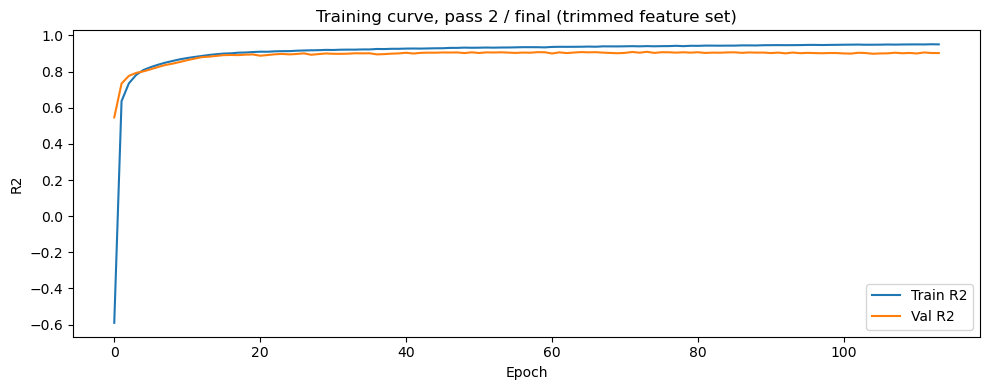

In [22]:
  # --------- reinitialize -----------------------------------------------------
np.random.seed(42)
team_table        = init_embedding(N_TEAMS,        TEAM_EMBED_DIM)
market_table      = init_embedding(N_MARKETS,      MARKET_EMBED_DIM)
window_table      = init_embedding(N_WINDOWS,      NET_EMBED_DIM)
div_matchup_table = init_embedding(N_DIV_MATCHUPS, DIV_EMBED_DIM)
W_interact        = init_embedding(TEAM_EMBED_DIM, MARKET_EMBED_DIM)
params            = init_params(layer_dims_trim, strategy='he')

adam_params  = init_adam_state(params)
adam_team    = init_embed_adam(team_table.shape)
adam_market  = init_embed_adam(market_table.shape)
adam_window  = init_embed_adam(window_table.shape)
adam_div     = init_embed_adam(div_matchup_table.shape)
adam_W       = init_embed_adam(W_interact.shape)

var_tr = float(np.var(ratings[tr]))
var_va = float(np.var(ratings[va]))

tr_losses2, va_losses2 = [], []
tr_r2s2,    va_r2s2    = [], []
best_val2, best_state2 = np.inf, None
no_improve2 = 0
t2 = 0

for epoch in range(n_epochs):
    perm  = np.random.permutation(tr)
    batch_losses = []

    for start in range(0, len(perm), batch_size):
        batch = perm[start : start + batch_size]
        t2 += 1

        X_b, offsets, cache_bx = build_input(
            home_teams[batch], away_teams[batch], markets[batch],
            window_codes[batch], div_codes[batch],
            numericals_trim[batch], team_table, market_table,
            window_table, div_matchup_table, W_interact,
            emb_keep_probs=emb_keep_probs if emb_dropout else None,
            training=True
        )
        AL, caches = forward_prop(X_b, params, output_activation='linear')
        batch_losses.append(mse_loss(AL, ratings[batch]))

        grads, dX = back_prop(AL, ratings[batch], caches, params)
        params, adam_params = update_params_adam(
            params, grads, adam_params, alpha, t2, beta1, beta2, eps_adam
        )

        d_team, d_market, d_window, d_div, dW = scatter_input_grad(
            dX, offsets, cache_bx, W_interact,
            home_teams[batch], away_teams[batch], markets[batch],
            window_codes[batch], div_codes[batch],
            team_table, market_table, window_table, div_matchup_table
        )
        team_table,        adam_team   = update_embed_adam(team_table,        d_team,   adam_team,   alpha, t2, beta1, beta2, eps_adam)
        market_table,      adam_market = update_embed_adam(market_table,      d_market, adam_market, alpha, t2, beta1, beta2, eps_adam)
        window_table,      adam_window = update_embed_adam(window_table,      d_window, adam_window, alpha, t2, beta1, beta2, eps_adam)
        div_matchup_table, adam_div    = update_embed_adam(div_matchup_table, d_div,    adam_div,    alpha, t2, beta1, beta2, eps_adam)
        W_interact,        adam_W      = update_embed_adam(W_interact,        dW,       adam_W,      alpha, t2, beta1, beta2, eps_adam)

    loss_tr = float(np.mean(batch_losses))

    X_va, _, _ = build_input(
        home_teams[va], away_teams[va], markets[va],
        window_codes[va], div_codes[va],
        numericals_trim[va], team_table, market_table,
        window_table, div_matchup_table, W_interact,
        emb_keep_probs=None, training=False
    )
    AL_va, _ = forward_prop(X_va, params, output_activation='linear')
    loss_va = mse_loss(AL_va, ratings[va])

    r2_tr = 1 - loss_tr / var_tr
    r2_va = 1 - loss_va / var_va

    tr_losses2.append(loss_tr);  va_losses2.append(loss_va)
    tr_r2s2.append(r2_tr);       va_r2s2.append(r2_va)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:4d} | train R2: {r2_tr:.4f} | val R2: {r2_va:.4f}')

    if loss_va < best_val2:
        best_val2   = loss_va
        best_state2 = {
            'params':            {k: v.copy() for k, v in params.items()},
            'team_table':        team_table.copy(),
            'market_table':      market_table.copy(),
            'window_table':      window_table.copy(),
            'div_matchup_table': div_matchup_table.copy(),
            'W_interact':        W_interact.copy(),
        }
        no_improve2 = 0
    else:
        no_improve2 += 1
        if no_improve2 >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val R2: {1 - best_val2 / var_va:.4f}')
            break

# ------------ restore best ------------------------------------------------------------
params, team_table, market_table, window_table, div_matchup_table, W_interact = (
    best_state2['params'],
    best_state2['team_table'],
    best_state2['market_table'],
    best_state2['window_table'],
    best_state2['div_matchup_table'],
    best_state2['W_interact'],
)

plt.figure(figsize=(10, 4))
plt.plot(tr_r2s2, label='Train R2')
plt.plot(va_r2s2, label='Val R2')
plt.xlabel('Epoch')
plt.ylabel('R2')
plt.title('Training curve, pass 2 / final (trimmed feature set)')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Inspect Learned Embeddings

After training we can inspect the embedding tables and the bilinear interaction
matrix to verify the network learned meaningful structure.

**Cosine similarity** between two embedding vectors measures how similar their
*directions* are: teams (or markets) that drive ratings in similar ways should
point in similar directions in embedding space, regardless of vector length.

**PCA projection** reduces the 16-dimensional team embeddings to 2D for
visualization. SVD finds the two directions of greatest variance; teams should
cluster by on-field relevance and market appeal rather than appearing random.

**Embedding norm** is a proxy for how much that entity drives rating variance.
Teams or markets that consistently differ from the average in predictable ways
tend to have larger norms.

**Code/label consistency check:** `ht_code` and `at_code` were encoded
separately via `pd.factorize`. If their orderings differ, the same team would
occupy different rows of `team_table` depending on whether it is home or away,
corrupting the shared embedding. The cell below verifies this before plotting.

**R_approx heatmap:**  the bilinear interaction matrix $W$ (shape 16×28) was
trained to factorize the linear model's 32×56 team×market coefficient table.
After training we can recover the full approximate table:

$$R_{\text{approx}} = E_{\text{team}} \cdot W \cdot E_{\text{market}}^\top \quad \text{shape }(32, 56)$$

High values indicate strong team×market affinity learned from the data.
Comparing this to the linear model's 32×56 coefficient table is a direct
interpretability check on whether the bilinear factorization recovered a similar structure.

ht_code / at_code are consistent -- shared team_table is valid.

Top-3 teams by embedding norm: ['CHIEF', 'STLRS', 'BRNCO']
Cosine similarity between them:
[[ 1.     0.153 -0.181]
 [ 0.153  1.     0.231]
 [-0.181  0.231  1.   ]]

Cosine similarity between top-3 and bottom-3:
[[ 0.25   0.04   0.059]
 [ 0.014 -0.235  0.1  ]
 [ 0.094 -0.053  0.063]]


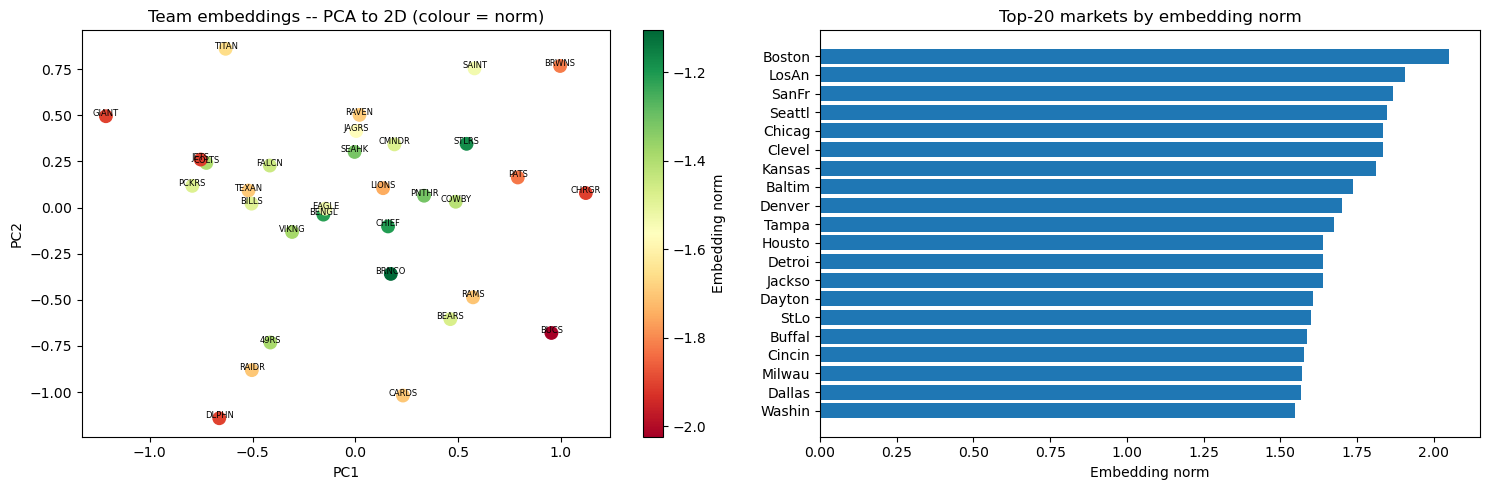

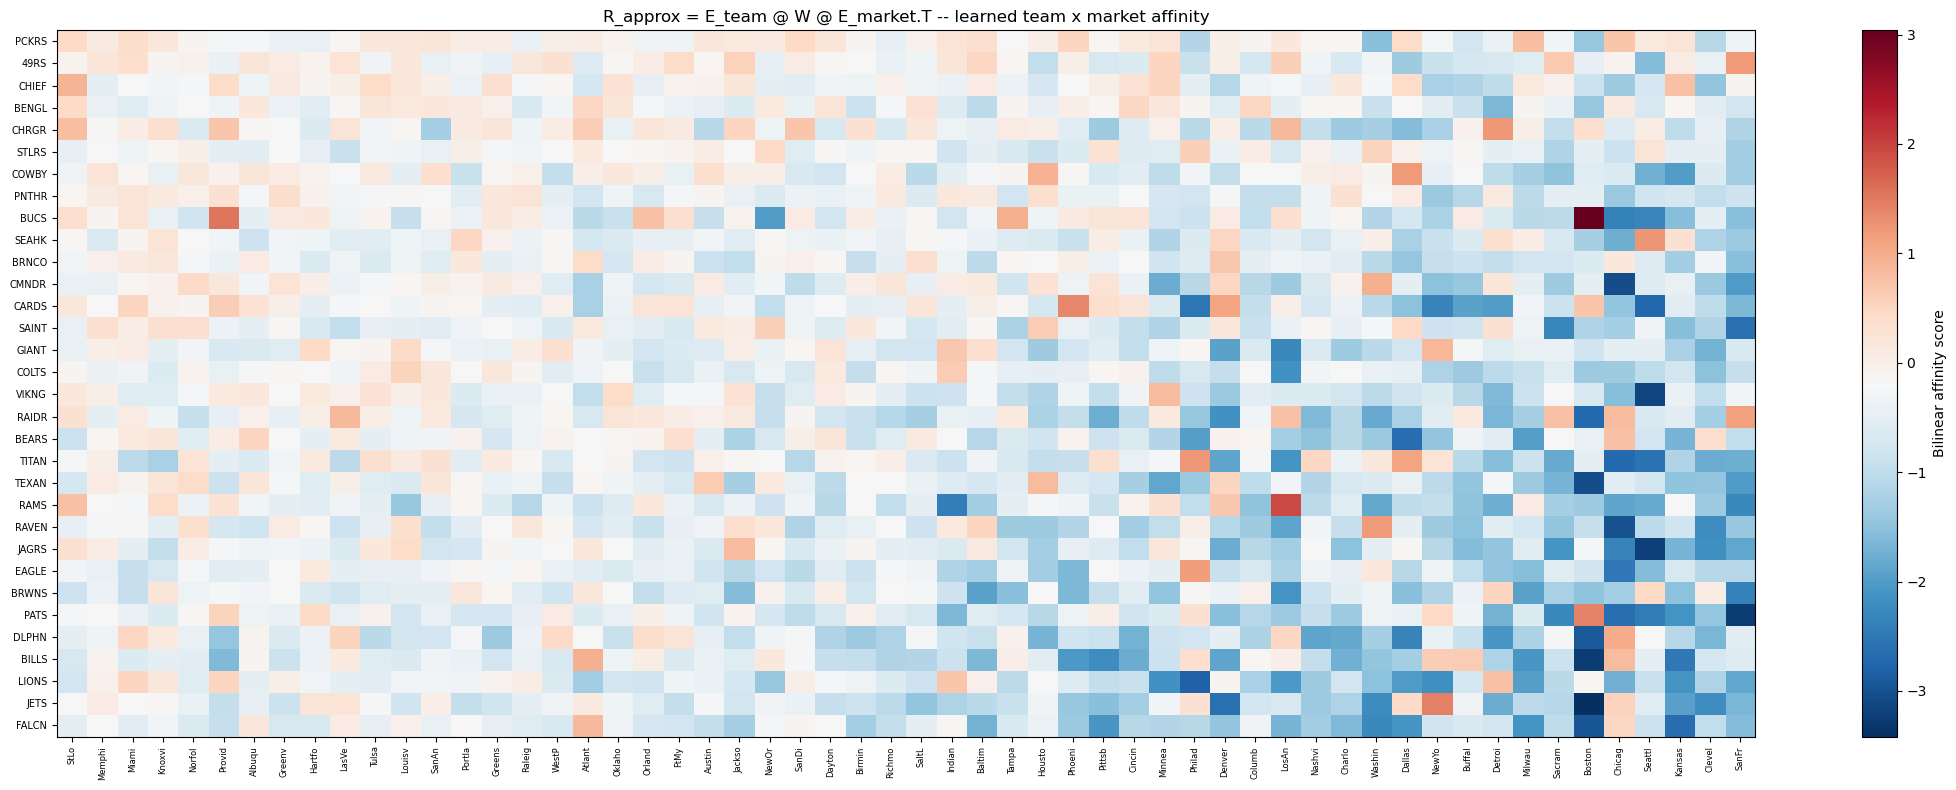


Team embedding norm range  : [-2.023, -1.105]
Market embedding norm range: [0.702, 2.048]
R_approx range             : [-3.417, 3.039]

Top-3 teams by norm: ['CHIEF', 'STLRS', 'BRNCO']
Bot-3 teams by norm: ['BUCS', 'JETS', 'CHRGR']


In [23]:
# -- 8. Inspect Learned Embeddings ------------------------------------------

# Build label lookups from df - avoids dependency on mapping variable names
team_label_map = (df[['ht_code', 'ht']].drop_duplicates()
                    .set_index('ht_code')['ht'].to_dict())
at_label_map   = (df[['at_code', 'at']].drop_duplicates()
                    .set_index('at_code')['at'].to_dict())
mkt_label_map  = (df[['Market_abrev_code', 'Market_abrev']].drop_duplicates()
                    .set_index('Market_abrev_code')['Market_abrev'].to_dict())

team_labels = [team_label_map.get(i, f'team_{i}') for i in range(N_TEAMS)]
mkt_labels  = [mkt_label_map.get(i,  f'mkt_{i}')  for i in range(N_MARKETS)]

# -- verify ht_code / at_code share the same team ordering -------------------
mismatches = {i: (team_labels[i], at_label_map.get(i, '?'))
              for i in range(N_TEAMS)
              if team_labels[i] != at_label_map.get(i, '?')}
if mismatches:
    print(f'WARNING: ht_code and at_code disagree on {len(mismatches)} team(s):')
    for code, (ht, at) in mismatches.items():
        print(f'  code {code:2d}: ht_mapping={ht}, at_mapping={at}')
else:
    print('ht_code / at_code are consistent -- shared team_table is valid.')

# -- team embedding norms and cosine similarity --------------------------------
embed_norms = -1*np.linalg.norm(team_table, axis=1)
normed = team_table / (embed_norms[:, None] + 1e-8)
cos_sim = normed @ normed.T

top3 = np.argsort(embed_norms)[-3:]
bot3 = np.argsort(embed_norms)[:3]

print('\nTop-3 teams by embedding norm:', [team_labels[i] for i in top3])
print('Cosine similarity between them:')
print(cos_sim[np.ix_(top3, top3)].round(3))
print('\nCosine similarity between top-3 and bottom-3:')
print(cos_sim[np.ix_(top3, bot3)].round(3))

# -- PCA of team embeddings + market norm bar chart ---------------------------
E = team_table - team_table.mean(axis=0)
_, _, Vt = np.linalg.svd(E, full_matrices=False)
proj = E @ Vt[:2].T

mkt_norms = np.linalg.norm(market_table, axis=1)
mkt_order = np.argsort(mkt_norms)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sc = axes[0].scatter(proj[:, 0], proj[:, 1], c=embed_norms, cmap='RdYlGn', s=80)
plt.colorbar(sc, ax=axes[0], label='Embedding norm')
for i in range(N_TEAMS):
    axes[0].annotate(team_labels[i], proj[i], fontsize=6, ha='center')
axes[0].set_title('Team embeddings -- PCA to 2D (colour = norm)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].barh([mkt_labels[i] for i in mkt_order[:20]], mkt_norms[mkt_order[:20]])
axes[1].set_xlabel('Embedding norm')
axes[1].set_title('Top-20 markets by embedding norm')
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

# -- W_interact: reconstruct team x market affinity table ---------------------
R_approx = -1 * (team_table @ W_interact @ market_table.T)   # (32, 56)

team_order = np.argsort(R_approx.mean(axis=1))[::-1]
mkt_sort = np.argsort(R_approx.mean(axis=0))[::-1]
R_sorted = R_approx[np.ix_(team_order, mkt_sort)]
row_labels = [team_labels[i] for i in team_order]
col_labels = [mkt_labels[i]  for i in mkt_sort]

fig, ax = plt.subplots(figsize=(22, 8))
im = ax.imshow(R_sorted, aspect='auto', cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='Bilinear affinity score')
ax.set_xticks(range(N_MARKETS))
ax.set_xticklabels(col_labels, rotation=90, fontsize=6)
ax.set_yticks(range(N_TEAMS))
ax.set_yticklabels(row_labels, fontsize=7)
ax.set_title('R_approx = E_team @ W @ E_market.T -- learned team x market affinity')
plt.tight_layout(); plt.show()

print(f'\nTeam embedding norm range  : [{embed_norms.min():.3f}, {embed_norms.max():.3f}]')
print(f'Market embedding norm range: [{mkt_norms.min():.3f}, {mkt_norms.max():.3f}]')
print(f'R_approx range             : [{R_approx.min():.3f}, {R_approx.max():.3f}]')
print('\nTop-3 teams by norm:', [team_labels[i] for i in top3])
print('Bot-3 teams by norm:', [team_labels[i] for i in bot3])


## 11. Analysis

Actual vs. predicted on held-out validation set.

  Val R²        : 0.9095  (raw scale)
  Val R² (log)  : 0.8583  (log1p scale)
  Val RMSE      : 38.50


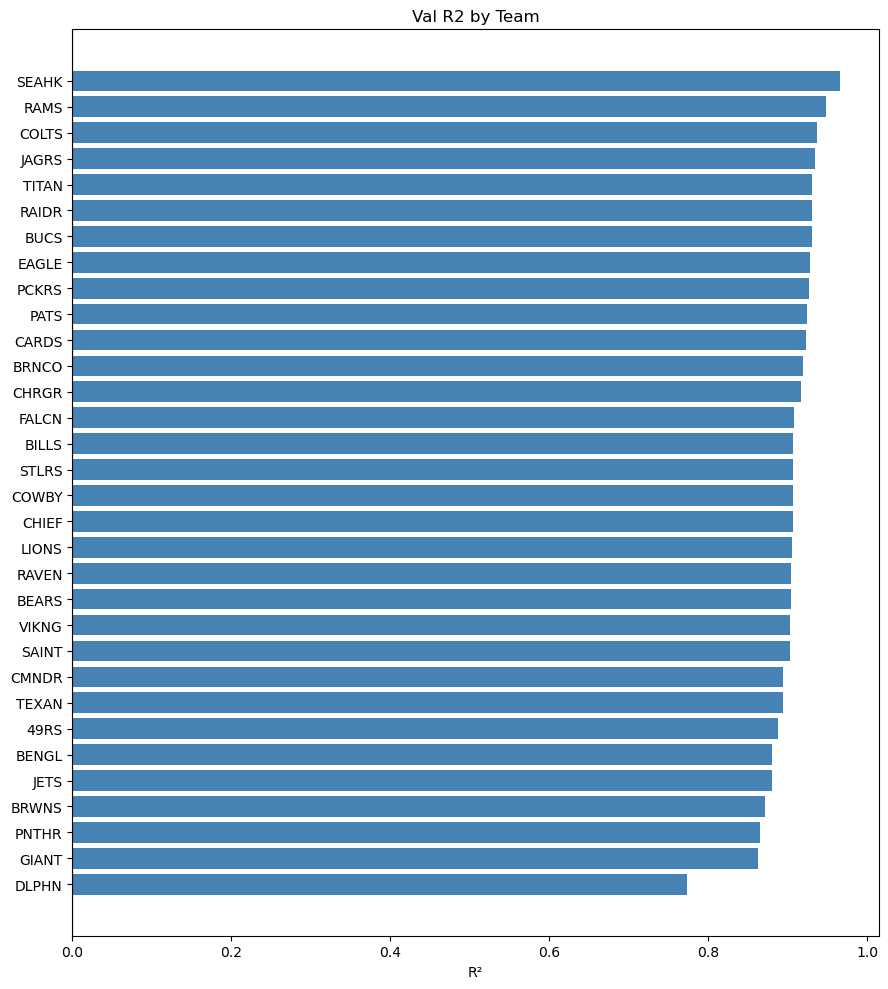

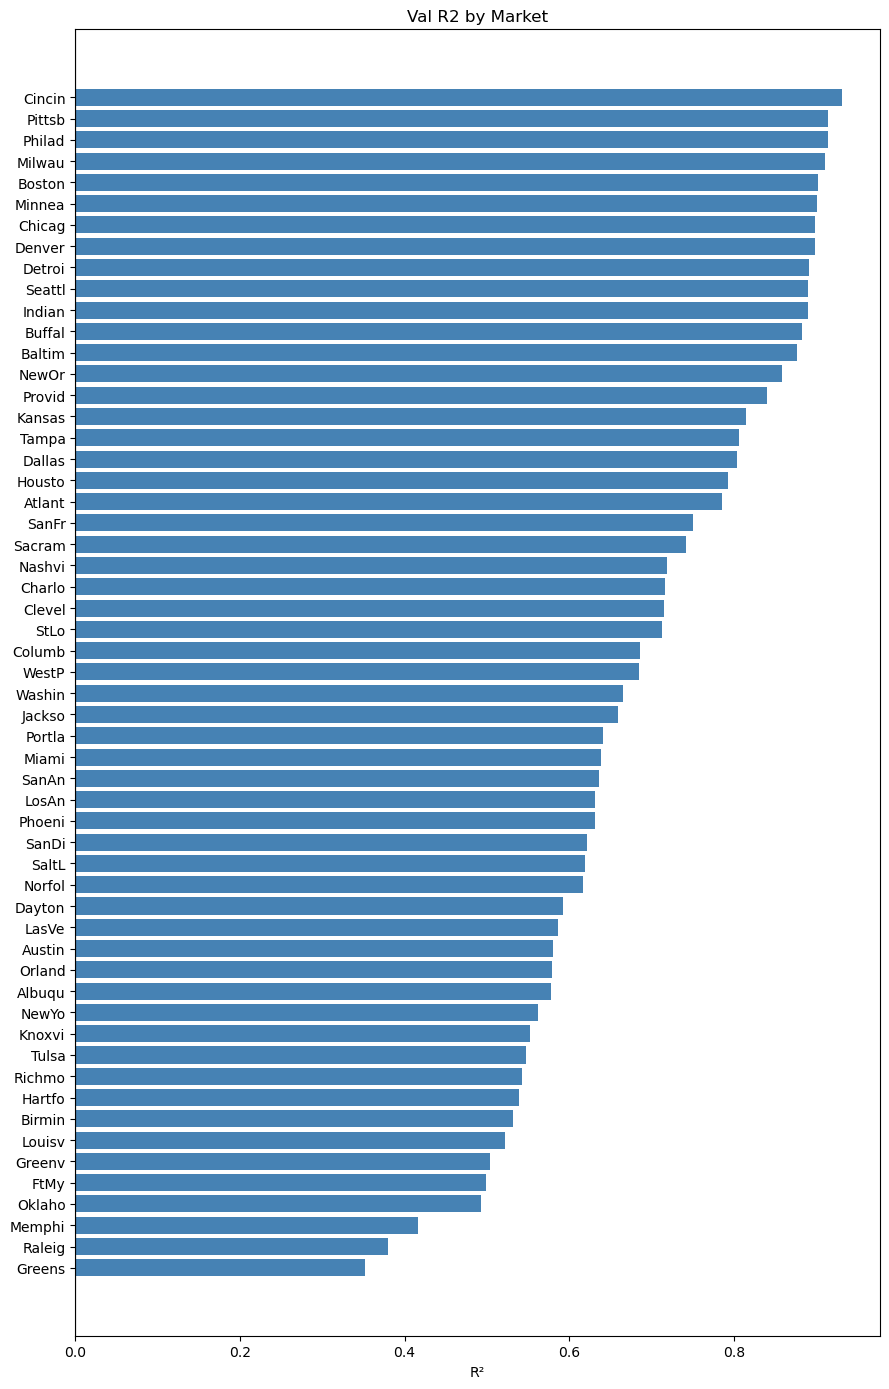

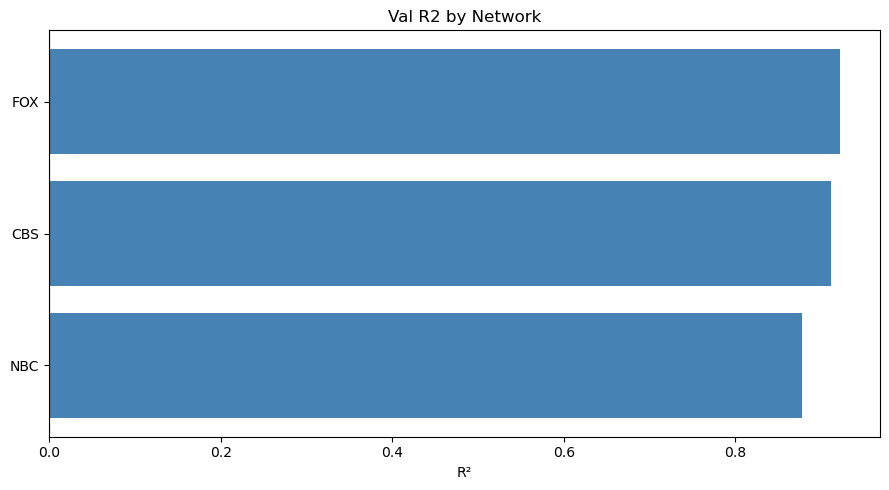


Rating tier accuracy (threshold = 150):
Tier                    n  mean_true  mean_pred     RMSE      MAE
--------------------------------------------------------------
< 150  (low)         2879       79.9       81.4    22.68    16.52
>= 150  (high)       1226      294.0      283.0    61.27    45.76


In [ ]:
#  11. Actual vs Predicted (Validation Set)

# Forward pass on the held-out val set, no dropout at inference
X_va, _, _ = build_input(
    home_teams[va], away_teams[va], markets[va],
    window_codes[va], div_codes[va],
    numericals_trim[va], team_table, market_table,
    window_table, div_matchup_table, W_interact,
    emb_keep_probs=None, training=False
)
y_pred_va, _ = forward_prop(X_va, params)
y_pred_va = y_pred_va.flatten()
y_true_va = ratings[va]


# --- Subset R squared breakdowns ----------------------------------------------
val_df = df.iloc[va].reset_index(drop=True)
home_rows = val_df[['ht', 'Market_abrev']].assign(y_true=y_true_va, y_pred=y_pred_va).rename(columns={'ht': 'team'})
away_rows = val_df[['at', 'Market_abrev']].assign(y_true=y_true_va, y_pred=y_pred_va).rename(columns={'at': 'team'})
val_team = pd.concat([home_rows, away_rows]).reset_index(drop=True)

plot_subset_r2(val_team['y_true'].values, val_team['y_pred'].values, val_team['team'].values,
               title='Val R2 by Team', figsize=(9, 10))
plot_subset_r2(y_true_va, y_pred_va, val_df['Market_abrev'].values,
               title='Val R2 by Market', figsize=(9, 14))
plot_subset_r2(y_true_va, y_pred_va, val_df['Affiliation'].values,
               title='Val R2 by Network', figsize=(9, 5))

# --- Rating tier accuracy (< 150 vs >= 150) ------------------------------------
print('\nRating tier accuracy (threshold = 150):')
print(f'{"Tier":<18} {"n":>6} {"mean_true":>10} {"mean_pred":>10} {"RMSE":>8} {"MAE":>8}')
print('-' * 62)
for label, mask in [('< 150  (low)', y_true_va < 150), ('>= 150  (high)', y_true_va >= 150)]:
    yt = y_true_va[mask]
    yp = y_pred_va[mask]
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    mae  = np.mean(np.abs(yt - yp))
    print(f'{label:<18} {mask.sum():>6} {yt.mean():>10.1f} {yp.mean():>10.1f} {rmse:>8.2f} {mae:>8.2f}')


Summary: the model is well calibrated in both tiers (slightly lower relative RMSE in the high tier, so a little more accurate on games that matter most) but the model shows a small reggression-to-the-mean bias (aggregate-overshoot on low-tier games, aggregate-undershoot on high tier-games). This is almost universal in ML regression models trained with MSE loss which penalizes large errors heavily and rewards conservative predictions. The 11 unit average miss on top tier games is about 4%, which is reasonable, but means individual game predictions could be off by around 60-120 units on high profile matchups. 

  Val R²        : 0.9095  (raw scale)
  Val R² (log)  : 0.8583  (log1p scale)
  Val RMSE      : 38.50


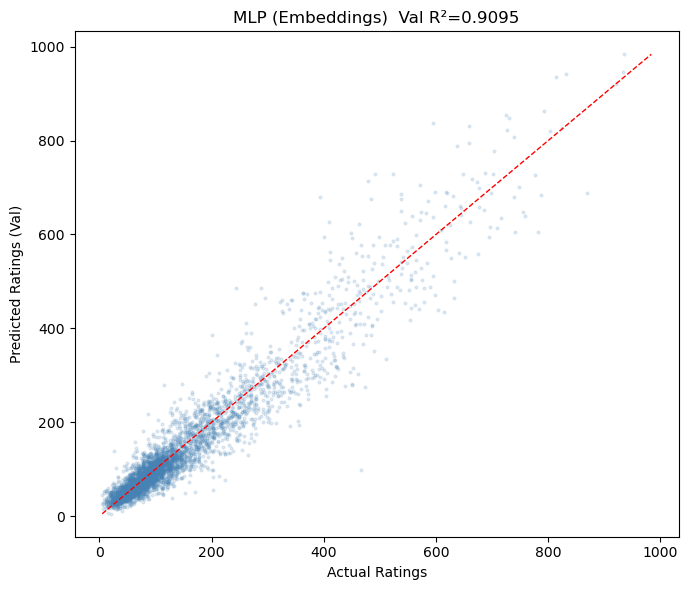

In [25]:
def plot_actual_vs_predicted(y_true, y_pred, title=''):
    # -- Actual vs Predicted (Validation Set) ----------------------------------
    val_r2   = r2_score(y_true, y_pred)
    val_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    print('=' * 50)
    print(f'  Val R²        : {val_r2:.4f}  (raw scale)')
    if np.all(y_pred > -1):
        val_r2_log = r2_score(np.log1p(y_true), np.log1p(y_pred))
        print(f'  Val R² (log)  : {val_r2_log:.4f}  (log1p scale)')
    else:
        n_neg = int(np.sum(y_pred <= -1))
        print(f'  Val R² (log)  : n/a  ({n_neg} predictions <= -1, log undefined)')
    print(f'  Val RMSE      : {val_rmse:.2f}')


    # -- scatter plot ----------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_true, y_pred, alpha=0.15, s=4, color='steelblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('Actual Ratings')
    ax.set_ylabel('Predicted Ratings (Val)')
    ax.set_title(f'{title}  Val R²={val_r2:.4f}' if title else f'Actual vs Predicted — Val R²={val_r2:.4f}')
    plt.tight_layout()
    # plt.show()
    plt.close(fig)
    return fig

plot_actual_vs_predicted(y_true_va, y_pred_va, title='MLP (Embeddings)')